<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/GLBasic3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [34]:

# =====================================================================
# MODULE 1: UNSUPERVISED REPRESENTATION LEARNING (SAAB TRANSFORM)
# =====================================================================
class TabularSaabTransform(BaseEstimator, TransformerMixin):
    def __init__(self, k_prime=0.95):
        self.k_prime = k_prime
        self.scaler = StandardScaler()
        self.pca = None
        self.bias_vector_ = None

    def fit(self, X, y=None):
        X_scaled = self.scaler.fit_transform(X)
        self.pca = PCA(n_components=self.k_prime, random_state=42)
        self.pca.fit(X_scaled)

        raw_responses = np.dot(X_scaled, self.pca.components_.T)
        self.bias_vector_ = np.abs(np.min(raw_responses, axis=0)) + 1e-5
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        ac_responses = np.dot(X_scaled, self.pca.components_.T)
        return ac_responses + self.bias_vector_


In [64]:
# Load the datasets
train_df_raw = pd.read_csv('/content/UNSW_NB15_training-set.csv')
test_df_raw = pd.read_csv('/content/UNSW_NB15_testing-set.csv')

# Drop unnecessary columns 'id' and 'label'
cols_to_drop = ['id', 'label']
train_df_raw = train_df_raw.drop(columns=cols_to_drop)
test_df_raw = test_df_raw.drop(columns=cols_to_drop)

print("Original training data shape:", train_df_raw.shape)
print("Original testing data shape:", test_df_raw.shape)

Original training data shape: (175341, 43)
Original testing data shape: (82332, 43)


### Feature Engineering: Adding Time-Based Features

We will create new features derived from existing time-related attributes (`dur`, `sinpkt`, `dinpkt`, `sjit`, `djit`) to capture more granular patterns that might differentiate 'Backdoor' from 'DoS' attacks. These features aim to highlight aspects like connection duration, inter-packet arrival time symmetry, and jitter characteristics.

In [85]:
def create_time_based_features(df):
    # Log transform of duration to handle skewed distribution, adding 1 to handle 0s
    df['log_dur'] = np.log1p(df['dur'])

    # Inter-packet arrival time difference (asymmetry)
    # Add a small epsilon to denominator to avoid division by zero if dinpkt is 0
    df['pkt_inter_arrival_diff'] = np.abs(df['sinpkt'] - df['dinpkt'])
    df['pkt_inter_arrival_ratio'] = df['sinpkt'] / (df['dinpkt'] + 1e-6)
    df.replace([np.inf, -np.inf], np.nan, inplace=True) # Handle potential inf values from division
    df.fillna(0, inplace=True) # Fill NaNs with 0 (or a more appropriate strategy)

    # Jitter difference (asymmetry in jitter)
    # Add a small epsilon to denominator to avoid division by zero if djit is 0
    df['jitter_diff'] = np.abs(df['sjit'] - df['djit'])
    df['jitter_ratio'] = df['sjit'] / (df['djit'] + 1e-6)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df

print("Applying time-based feature engineering...")
train_df_raw = create_time_based_features(train_df_raw)
test_df_raw = create_time_based_features(test_df_raw)

print("Train data shape after feature engineering:", train_df_raw.shape)
print("Test data shape after feature engineering:", test_df_raw.shape)

# Update numeric_cols to include the new features for subsequent steps
new_time_features = ['log_dur', 'pkt_inter_arrival_diff', 'pkt_inter_arrival_ratio', 'jitter_diff', 'jitter_ratio']
numeric_cols.extend(new_time_features)

print("New time-based features added to numeric_cols.")


Applying time-based feature engineering...
Train data shape after feature engineering: (175341, 48)
Test data shape after feature engineering: (82332, 48)
New time-based features added to numeric_cols.


In [65]:
# Identify categorical and numerical columns (excluding the target 'attack_cat')
categorical_cols = ['proto', 'service', 'state']
numeric_cols = [col for col in train_df_raw.columns if col not in categorical_cols + ['attack_cat']]

# Apply one-hot encoding to categorical features
train_df_encoded = pd.get_dummies(train_df_raw, columns=categorical_cols, drop_first=False)
test_df_encoded = pd.get_dummies(test_df_raw, columns=categorical_cols, drop_first=False)

# Align columns - very important for consistent feature sets after one-hot encoding
train_cols = set(train_df_encoded.columns)
test_cols = set(test_df_encoded.columns)

common_cols = list(train_cols.intersection(test_cols))

# Ensure 'attack_cat' is kept if it's in common_cols, then remove it for feature alignment
if 'attack_cat' in common_cols:
    common_cols.remove('attack_cat')

# Add missing columns to each DataFrame with 0s
for col in train_cols - test_cols:
    if col != 'attack_cat': # Don't add target column as a feature
        test_df_encoded[col] = 0
for col in test_cols - train_cols:
    if col != 'attack_cat': # Don't add target column as a feature
        train_df_encoded[col] = 0

# Reorder columns to ensure they are identical, putting 'attack_cat' last if present
feature_cols_aligned = sorted([col for col in train_df_encoded.columns if col != 'attack_cat'])

train_df_encoded = train_df_encoded[feature_cols_aligned + ['attack_cat']]
test_df_encoded = test_df_encoded[feature_cols_aligned + ['attack_cat']]

print("Aligned training data shape:", train_df_encoded.shape)
print("Aligned testing data shape:", test_df_encoded.shape)

Aligned training data shape: (175341, 197)
Aligned testing data shape: (82332, 197)


In [66]:
# Separate features (X) and target labels (y)
X_train_raw = train_df_encoded.drop(columns=['attack_cat'])
y_train_raw = train_df_encoded['attack_cat']

X_test_raw = test_df_encoded.drop(columns=['attack_cat'])
y_test_raw = test_df_encoded['attack_cat']

# Encode multi-class labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# Store class names for reference
class_names = label_encoder.classes_
print(f"Encoded {len(class_names)} classes: {list(class_names)}")

Encoded 10 classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [67]:
# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert back to DataFrame to preserve column names (optional, but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (175341, 196)
X_test_scaled shape: (82332, 196)


In [68]:
# Apply TabularSaabTransform for unsupervised representation learning
tabular_saab = TabularSaabTransform(k_prime=0.95)
X_train_processed = tabular_saab.fit_transform(X_train_scaled)
X_test_processed = tabular_saab.transform(X_test_scaled)

print("X_train_processed shape after SAAB Transform:", X_train_processed.shape)
print("X_test_processed shape after SAAB Transform:", X_test_processed.shape)

X_train_processed shape after SAAB Transform: (175341, 153)
X_test_processed shape after SAAB Transform: (82332, 153)


In [63]:

# =====================================================================
# MODULE 2: SUPERVISED FEATURE LEARNING (MULTI-CLASS DFT)
# =====================================================================
class MultiClassDiscriminantFeatureTest(BaseEstimator, TransformerMixin):
    def __init__(self, percentile_threshold=70):
        self.percentile_threshold = percentile_threshold
        self.selected_indices_ = []

    def _calculate_entropy(self, y):
        if len(y) == 0: return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-9))

    def fit(self, X, y):
        num_features = X.shape[1]
        feature_costs = []
        y = np.array(y)

        for i in range(num_features):
            f_col = X[:, i]
            thresholds = np.percentile(f_col, [25, 50, 75])
            best_entropy = float('inf')

            for t in thresholds:
                left_mask = f_col < t
                entropy_split = (
                    (np.sum(left_mask) / len(y)) * self._calculate_entropy(y[left_mask]) +
                    (np.sum(~left_mask) / len(y)) * self._calculate_entropy(y[~left_mask])
                )
                if entropy_split < best_entropy:
                    best_entropy = entropy_split
            feature_costs.append(best_entropy)

        cost_cutoff = np.percentile(feature_costs, self.percentile_threshold)
        self.selected_indices_ = [idx for idx, cost in enumerate(feature_costs) if cost <= cost_cutoff]
        return self

    def transform(self, X):
        return X[:, self.selected_indices_]

# --- Initiation of MultiClass Feature Selection for all attack types ---
# The user requested to "classify all kinds attack," indicating a shift back to the full multi-class problem.
# The MultiClassDiscriminantFeatureTest is a component for feature selection in such a pipeline.
# This code block initializes and fits the MultiClassDiscriminantFeatureTest on the full multi-class
# training data. It assumes that X_train_processed (features) and y_train_encoded (labels)
# for the *full multi-class dataset* have been prepared and are available in the environment
# from earlier steps of the overall multi-class pipeline setup.

print("\n--- Initiating MultiClass Feature Selection for all attack types ---")
try:
    # Use the appropriate multi-class training data.
    # The variable names 'X_train_processed' and 'y_train_encoded' are placeholders
    # for the preprocessed features and encoded labels of the full multi-class dataset.
    # If these variables are named differently in your notebook (e.g., from an initial pipeline run),
    # please adjust them accordingly.

    # The following lines will trigger a NameError if X_train_processed or y_train_encoded are not defined.
    # This is intentional to inform the user about missing data.
    X_data_for_fit = X_train_processed.values if isinstance(X_train_processed, pd.DataFrame) else X_train_processed
    y_data_for_fit = y_train_encoded

    dft_multi_class = MultiClassDiscriminantFeatureTest(percentile_threshold=70)
    dft_multi_class.fit(X_data_for_fit, y_data_for_fit)
    print(f"MultiClassDiscriminantFeatureTest fitted for multi-class data. Selected {len(dft_multi_class.selected_indices_)} features.")
    print("You can now use 'dft_multi_class.transform(X_data)' to apply this feature selection.")

except NameError as ne:
    print(f"Error: Required multi-class training data variable not found: {ne}")
    print("Please ensure you have run the data preprocessing steps for the full UNSW-NB15 multi-class dataset ")
    print("and that the variables like 'X_train_processed' and 'y_train_encoded' are correctly named in the global scope.")
    print("This step demonstrates the intended usage of MultiClassDiscriminantFeatureTest within a full pipeline.")
except Exception as e:
    print(f"An unexpected error occurred during MultiClassDiscriminantFeatureTest fitting: {e}")

print("------------------------------------------------------------------")



--- Initiating MultiClass Feature Selection for all attack types ---
Error: Required multi-class training data variable not found: name 'X_train_processed' is not defined
Please ensure you have run the data preprocessing steps for the full UNSW-NB15 multi-class dataset 
and that the variables like 'X_train_processed' and 'y_train_encoded' are correctly named in the global scope.
This step demonstrates the intended usage of MultiClassDiscriminantFeatureTest within a full pipeline.
------------------------------------------------------------------


In [69]:
print('\n--- Now running MultiClass Feature Selection (MultiClassDiscriminantFeatureTest) ---')
# The variables X_train_processed and y_train_encoded are now available.

X_data_for_fit = X_train_processed
y_data_for_fit = y_train_encoded

dft_multi_class = MultiClassDiscriminantFeatureTest(percentile_threshold=70)
dft_multi_class.fit(X_data_for_fit, y_data_for_fit)

print(f"MultiClassDiscriminantFeatureTest fitted for multi-class data. Selected {len(dft_multi_class.selected_indices_)} features.")

X_train_selected = dft_multi_class.transform(X_train_processed)
X_test_selected = dft_multi_class.transform(X_test_processed)

print("X_train_selected shape after feature selection:", X_train_selected.shape)
print("X_test_selected shape after feature selection:", X_test_selected.shape)
print("------------------------------------------------------------------")


--- Now running MultiClass Feature Selection (MultiClassDiscriminantFeatureTest) ---
MultiClassDiscriminantFeatureTest fitted for multi-class data. Selected 107 features.
X_train_selected shape after feature selection: (175341, 107)
X_test_selected shape after feature selection: (82332, 107)
------------------------------------------------------------------


In [70]:
print('\n--- Training SLMTreeClassifier for Multi-Class Classification ---')

# Initialize the SLMTreeClassifier for multi-class classification
slm_multi_class = SLMTreeClassifier(max_depth=10, min_samples_split=10, num_proj_candidates=50, random_state=42)

# Train the classifier on the selected features and encoded multi-class labels
# Ensure to convert X_train_selected to numpy array if it's not already, as SLMTreeClassifier expects it.
slm_multi_class.fit(X_train_selected, y_train_encoded)

print('SLMTreeClassifier multi-class training complete.')

# Make predictions on the test set using the trained multi-class classifier
y_pred_multi_class = slm_multi_class.predict(X_test_selected)

# Generate and print the classification report
# We need the original class names to interpret the report clearly.
report_multi_class = classification_report(y_test_encoded, y_pred_multi_class, target_names=class_names)
print('\n--- Multi-Class Classification Report (SLMTreeClassifier) ---')
print(report_multi_class)
print('------------------------------------------------------------')


--- Training SLMTreeClassifier for Multi-Class Classification ---
SLMTreeClassifier multi-class training complete.

--- Multi-Class Classification Report (SLMTreeClassifier) ---
                precision    recall  f1-score   support

      Analysis       0.07      0.05      0.06       677
      Backdoor       0.02      0.01      0.01       583
           DoS       0.20      0.03      0.05      4089
      Exploits       0.50      0.82      0.62     11132
       Fuzzers       0.23      0.58      0.33      6062
       Generic       0.99      0.95      0.97     18871
        Normal       0.96      0.65      0.77     37000
Reconnaissance       0.48      0.57      0.52      3496
     Shellcode       0.23      0.22      0.22       378
         Worms       1.00      0.02      0.04        44

      accuracy                           0.69     82332
     macro avg       0.47      0.39      0.36     82332
  weighted avg       0.78      0.69      0.71     82332

----------------------------------

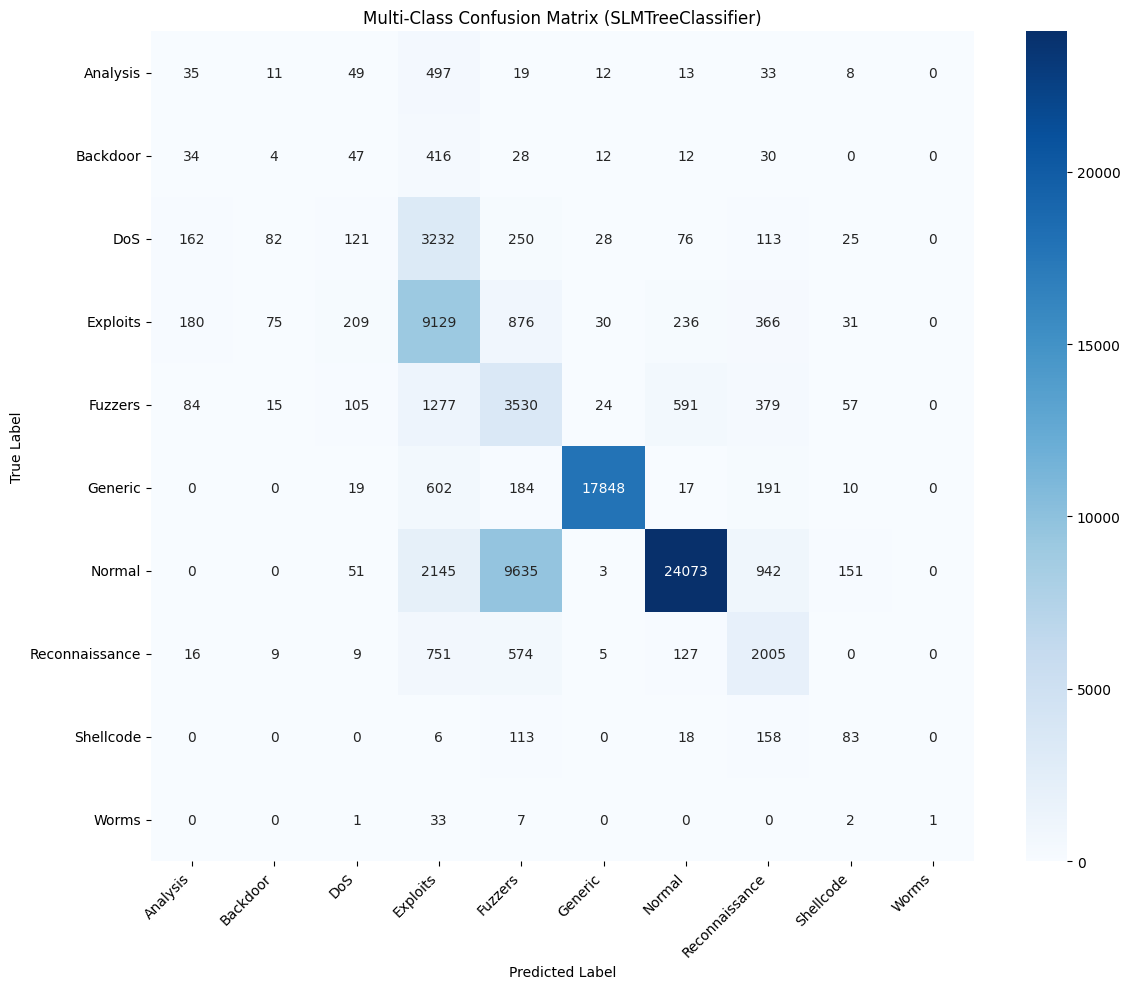

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix for the multi-class model
cm_multi_class = confusion_matrix(y_test_encoded, y_pred_multi_class)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi_class, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multi-Class Confusion Matrix (SLMTreeClassifier)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [72]:
# Get the encoded labels for 'Backdoor', 'Exploits', and 'Normal'
backdoor_label = label_encoder.transform(['Backdoor'])[0]
exploits_label = label_encoder.transform(['Exploits'])[0]
normal_label = label_encoder.transform(['Normal'])[0]

print(f"Encoded labels: Backdoor={backdoor_label}, Exploits={exploits_label}, Normal={normal_label}")

# Identify misclassified 'Backdoor' samples
# True label is 'Backdoor' (index 1), but predicted label is not 'Backdoor'

misclassified_backdoor_mask = (
    (y_test_encoded == backdoor_label) &
    (y_pred_multi_class != backdoor_label)
)

# Specifically, 'Backdoor' misclassified as 'Exploits' or 'Normal'
misclassified_backdoor_as_exploits_mask = (
    (y_test_encoded == backdoor_label) &
    (y_pred_multi_class == exploits_label)
)

misclassified_backdoor_as_normal_mask = (
    (y_test_encoded == backdoor_label) &
    (y_pred_multi_class == normal_label)
)

X_misclassified_backdoor = X_test_selected[misclassified_backdoor_mask]
X_misclassified_backdoor_as_exploits = X_test_selected[misclassified_backdoor_as_exploits_mask]
X_misclassified_backdoor_as_normal = X_test_selected[misclassified_backdoor_as_normal_mask]

print(f"Total 'Backdoor' samples misclassified: {X_misclassified_backdoor.shape[0]}")
print(f"'Backdoor' samples misclassified as 'Exploits': {X_misclassified_backdoor_as_exploits.shape[0]}")
print(f"'Backdoor' samples misclassified as 'Normal': {X_misclassified_backdoor_as_normal.shape[0]}")

Encoded labels: Backdoor=1, Exploits=3, Normal=6
Total 'Backdoor' samples misclassified: 579
'Backdoor' samples misclassified as 'Exploits': 416
'Backdoor' samples misclassified as 'Normal': 12


### Descriptive Statistics for Misclassified 'Backdoor' Samples (Predicted as 'Exploits')

In [73]:
if X_misclassified_backdoor_as_exploits.shape[0] > 0:
    # Since X_test_selected is a numpy array, we can convert to DataFrame for easier describe()
    df_misclassified_backdoor_as_exploits = pd.DataFrame(X_misclassified_backdoor_as_exploits)
    display(df_misclassified_backdoor_as_exploits.describe())
else:
    print("No 'Backdoor' samples misclassified as 'Exploits' to analyze.")

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
count,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,...,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000
mean,7.876075,18.321633,5.216096,46.912409,8.675485,18.143064,12.298332,17.286284,13.470644,32.935835,...,12.283437,10.898941,12.376081,3.754066,17.937724,29.281593,79.992262,10.770716,49.836641,141.020084
std,0.973033,0.222008,0.539765,0.409435,0.744143,1.862063,2.276064,1.694107,1.791738,2.539652,...,2.705920,3.492363,3.186711,3.079524,3.412963,2.910359,0.289220,0.262624,0.206462,0.156837
min,6.319799,16.343681,3.989976,45.750963,5.197488,13.036423,-0.000013,-0.000219,0.001352,22.036966,...,0.000010,0.000006,-0.000015,0.000019,0.000009,0.000010,78.779771,9.480118,49.119243,139.242723
25%,7.496918,18.283954,5.097765,46.833698,8.386164,17.779251,12.461466,17.284310,12.962206,33.002874,...,12.512824,10.690736,12.391085,3.194538,17.865268,29.427678,79.947566,10.798538,49.766348,141.002016
50%,7.781007,18.307377,5.132541,46.868019,8.885477,18.293119,12.470925,17.410194,13.566270,33.030498,...,12.512824,10.781667,12.391117,3.629612,17.865567,29.427678,80.076764,10.798749,49.828901,141.023270
75%,8.033934,18.317066,5.236455,46.956896,8.887374,18.296064,12.482278,17.411172,13.567688,33.619334,...,12.512824,10.783076,12.401069,3.629721,17.890235,29.427678,80.077045,10.828756,49.838627,141.050709
max,14.125407,19.492327,9.888342,50.343654,14.009698,35.897150,35.015475,25.566867,27.959593,46.573610,...,41.719687,37.250983,31.829954,28.271583,52.509132,59.813349,81.370950,11.450853,50.821261,141.386920


### Descriptive Statistics for Misclassified 'Backdoor' Samples (Predicted as 'Normal')

In [74]:
if X_misclassified_backdoor_as_normal.shape[0] > 0:
    df_misclassified_backdoor_as_normal = pd.DataFrame(X_misclassified_backdoor_as_normal)
    display(df_misclassified_backdoor_as_normal.describe())
else:
    print("No 'Backdoor' samples misclassified as 'Normal' to analyze.")

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,...,1.200000e+01,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,12.534050,17.207764,5.041741,46.705239,8.901304,17.652618,12.369253,17.465766,13.366610,33.600765,...,1.251282e+01,10.793702,15.628326,3.955170,15.164004,34.491956,79.925875,10.857761,49.794017,141.007634
std,2.240186,0.658487,0.431379,0.395343,0.022439,1.438934,0.228434,0.137124,0.445839,1.339208,...,8.584159e-10,0.029940,7.560311,0.761211,6.309804,11.827607,0.349529,0.128517,0.070042,0.006629
min,7.770276,16.238699,4.175426,45.850815,8.879857,14.572253,11.880222,17.404582,12.412149,33.014332,...,1.251282e+01,10.780477,12.391138,3.629023,1.655522,29.427678,79.177580,10.801177,49.644088,140.994590
25%,13.172815,16.783971,4.942922,46.604861,8.890399,18.250676,12.465133,17.406424,13.554648,33.025562,...,1.251282e+01,10.780597,12.391191,3.629088,17.865575,29.427678,80.074589,10.802686,49.822658,141.007734
50%,13.397385,17.031196,5.128373,46.838706,8.894532,18.262004,12.466218,17.407137,13.556180,33.029443,...,1.251282e+01,10.780707,12.391205,3.629147,17.865730,29.427678,80.075401,10.802918,49.823824,141.009702
75%,13.577830,17.619643,5.264449,46.898479,8.899841,18.273483,12.467289,17.409270,13.557480,33.033951,...,1.251282e+01,10.781670,12.391224,3.629661,17.865747,29.427678,80.075707,10.803478,49.824058,141.010349
max,14.106707,18.290126,5.702989,47.331461,8.947108,18.304005,12.471009,17.759317,13.563789,36.467809,...,1.251282e+01,10.857790,31.813985,5.584824,17.865770,59.813349,80.077138,11.132897,49.827290,141.017853


In [75]:
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

print('\n--- Training LGBMClassifier with Class Weights for Multi-Class Classification ---')

# Calculate class weights to handle imbalance
# The 'balanced' mode automatically adjusts weights inversely proportional to class frequencies.
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weights_dict = {i : class_weights[i] for i in range(len(class_weights))}

print(f"Computed class weights: {class_weights_dict}")

# Initialize LGBMClassifier with class weights
lgbm_multi_class = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(class_names),
    class_weight=class_weights_dict,
    random_state=42,
    n_estimators=500, # Increased estimators for potentially better performance
    learning_rate=0.05,
    num_leaves=31
)

# Train the classifier
lgbm_multi_class.fit(X_train_selected, y_train_encoded)

print('LGBMClassifier multi-class training complete.')

# Make predictions on the test set
y_pred_lgbm_multi_class = lgbm_multi_class.predict(X_test_selected)

# Generate and print the classification report
report_lgbm_multi_class = classification_report(y_test_encoded, y_pred_lgbm_multi_class, target_names=class_names)
print('\n--- Multi-Class Classification Report (LGBMClassifier with Class Weights) ---')
print(report_lgbm_multi_class)
print('--------------------------------------------------------------------------------')


--- Training LGBMClassifier with Class Weights for Multi-Class Classification ---
Computed class weights: {0: np.float64(8.76705), 1: np.float64(10.042439862542956), 2: np.float64(1.4297211350293542), 3: np.float64(0.5250831012487647), 4: np.float64(0.9642597888253409), 5: np.float64(0.4383525), 6: np.float64(0.3131089285714286), 7: np.float64(1.6713468687446382), 8: np.float64(15.475816416593116), 9: np.float64(134.8776923076923)}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.542411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27285
[LightGBM] [Info] Number of data points in the train set: 175341, number of used features: 107
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Multi-Class Classification Report (LGBMClassifier with Class Weights) ---
                precision    recall  f1-score   support

      Analysis       0.03      0.12      0.05       677
      Backdoor       0.05      0.46      0.08       583
           DoS       0.25      0.16      0.19      4089
      Exploits       0.76      0.54      0.63     11132
       Fuzzers       0.23      0.60      0.33      6062
       Generic       1.00      0.96      0.98     18871
        Normal       0.98      0.60      0.74     37000
Reconnaissance       0.52      0.82      0.63      3496
     Shellcode       0.23      0.65      0.34       378
         Worms       0.36      0.11      0.17        44

      accuracy                           0.66     82332
     macro avg       0.44      0.50      0.42     82332
  weighted avg       0.83      0.66      0.71     82332

--------------------------------------------------------------------------------


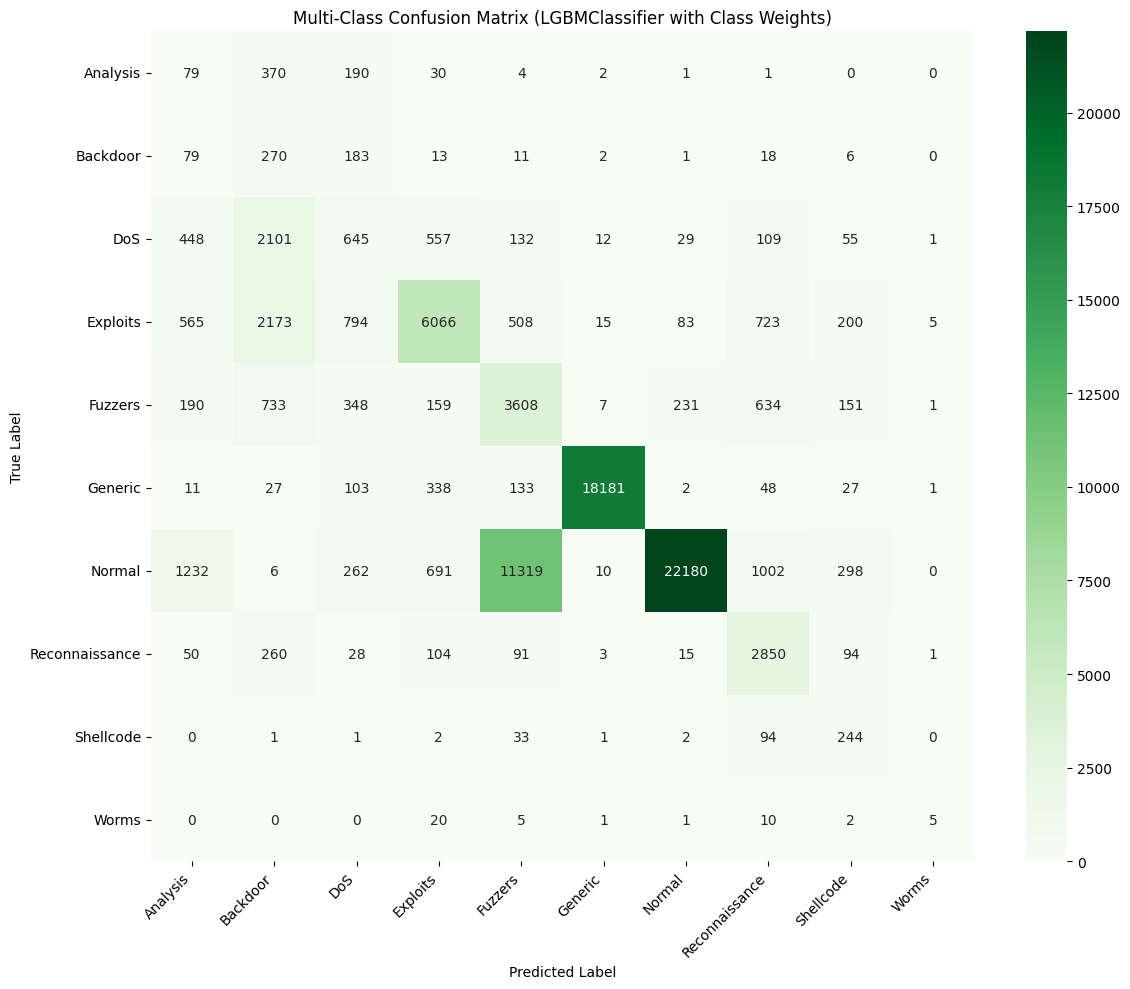

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix for the LGBM multi-class model
cm_lgbm_multi_class = confusion_matrix(y_test_encoded, y_pred_lgbm_multi_class)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_lgbm_multi_class, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multi-Class Confusion Matrix (LGBMClassifier with Class Weights)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
# Get encoded labels for target misclassification classes
dos_label = label_encoder.transform(['DoS'])[0]
analysis_label = label_encoder.transform(['Analysis'])[0]

# Identify 'Backdoor' samples misclassified as 'DoS' by LGBM
misclassified_backdoor_as_dos_mask_lgbm = (
    (y_test_encoded == backdoor_label) &
    (y_pred_lgbm_multi_class == dos_label)
)

# Identify 'Backdoor' samples misclassified as 'Analysis' by LGBM
misclassified_backdoor_as_analysis_mask_lgbm = (
    (y_test_encoded == backdoor_label) &
    (y_pred_lgbm_multi_class == analysis_label)
)

X_misclassified_backdoor_as_dos_lgbm = X_test_selected[misclassified_backdoor_as_dos_mask_lgbm]
X_misclassified_backdoor_as_analysis_lgbm = X_test_selected[misclassified_backdoor_as_analysis_mask_lgbm]

print(f"'Backdoor' samples misclassified as 'DoS' by LGBM: {X_misclassified_backdoor_as_dos_lgbm.shape[0]}")
print(f"'Backdoor' samples misclassified as 'Analysis' by LGBM: {X_misclassified_backdoor_as_analysis_lgbm.shape[0]}")

'Backdoor' samples misclassified as 'DoS' by LGBM: 183
'Backdoor' samples misclassified as 'Analysis' by LGBM: 79


### Descriptive Statistics for LGBM Misclassified 'Backdoor' Samples (Predicted as 'DoS')

In [78]:
if X_misclassified_backdoor_as_dos_lgbm.shape[0] > 0:
    df_misclassified_backdoor_as_dos_lgbm = pd.DataFrame(X_misclassified_backdoor_as_dos_lgbm)
    display(df_misclassified_backdoor_as_dos_lgbm.describe())
else:
    print("No 'Backdoor' samples misclassified as 'DoS' by LGBM to analyze.")

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,...,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,7.660909,18.307110,5.097942,46.839395,8.522907,17.562003,12.120646,17.396253,13.282321,32.814622,...,12.320518,10.606307,12.487710,4.279554,17.953371,29.588484,79.914134,10.770642,49.849007,141.053917
std,0.952897,0.154901,0.273819,0.250966,0.656720,1.539625,3.420592,1.569486,1.395176,2.738932,...,3.561188,4.469275,4.974863,5.248301,5.264043,4.972376,0.334936,0.292346,0.270220,0.129603
min,6.277239,17.111407,3.989976,45.850815,7.191664,13.036423,-0.000013,12.371249,7.661951,22.036966,...,0.000010,0.000006,-0.000015,0.000019,0.000009,0.000010,78.779771,9.834097,49.263484,140.812108
25%,7.314095,18.280153,5.058728,46.810894,8.035279,17.087453,12.373871,17.262682,12.498069,32.041013,...,12.512824,10.515786,12.112649,2.790396,17.854908,29.427677,79.794226,10.652483,49.724029,140.974543
50%,7.529402,18.301087,5.113932,46.860260,8.477943,17.803805,12.470969,17.409729,13.083339,33.030963,...,12.512824,10.668170,12.391114,3.374874,17.889585,29.427678,79.973867,10.802404,49.777849,141.023598
75%,7.888141,18.317447,5.190292,46.929011,8.887422,18.294815,12.588821,17.504007,13.631934,34.412071,...,12.512824,10.828229,12.618386,3.661549,17.948256,29.427678,80.076941,10.972351,49.861828,141.117293
max,13.759280,18.900072,6.016931,47.573045,10.572358,22.739110,35.015475,25.566867,17.049612,37.859426,...,23.532137,37.250983,31.829954,28.271583,52.509132,59.813349,80.807391,11.212833,50.821261,141.386920


### Descriptive Statistics for LGBM Misclassified 'Backdoor' Samples (Predicted as 'Analysis')

In [79]:
if X_misclassified_backdoor_as_analysis_lgbm.shape[0] > 0:
    df_misclassified_backdoor_as_analysis_lgbm = pd.DataFrame(X_misclassified_backdoor_as_analysis_lgbm)
    display(df_misclassified_backdoor_as_analysis_lgbm.describe())
else:
    print("No 'Backdoor' samples misclassified as 'Analysis' by LGBM to analyze.")

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,...,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,7.773329,18.306795,5.142373,46.869608,8.759350,18.340482,13.234698,17.791638,13.845876,32.811789,...,12.491906,11.445835,12.656338,3.669576,17.640759,29.055175,80.059715,10.725850,49.832974,141.003813
std,0.432489,0.041878,0.147756,0.138965,0.683445,1.287158,3.761600,3.167872,3.059449,2.495171,...,0.131827,2.820892,2.190750,0.797980,2.010623,3.310871,0.143979,0.287071,0.186672,0.101281
min,6.420371,18.123440,4.943797,46.639152,5.637509,14.329655,11.881611,13.645733,7.661602,22.641647,...,11.679154,10.192841,11.875155,0.015481,0.000011,0.000010,79.175952,9.480118,49.409311,140.629695
25%,7.586026,18.298877,5.084613,46.830263,8.885508,18.293309,12.470764,17.410129,13.566197,33.029976,...,12.512824,10.781666,12.391100,3.629612,17.865564,29.427678,80.076781,10.798566,49.828778,141.022820
50%,7.829263,18.315317,5.111984,46.836017,8.886299,18.294258,12.470953,17.410227,13.566438,33.030474,...,12.512824,10.781667,12.391109,3.629631,17.865565,29.427678,80.076894,10.798685,49.828902,141.023057
75%,8.029173,18.317365,5.146646,46.869909,8.887133,18.294882,12.471110,17.410485,13.567148,33.032148,...,12.512824,10.781669,12.391137,3.629642,17.865567,29.427678,80.077082,10.798763,49.829077,141.023271
max,8.772600,18.408590,5.866390,47.535006,10.567732,24.202037,35.015949,36.930285,31.031461,37.875121,...,12.517758,26.252321,31.829929,6.182577,18.013572,29.427678,80.291263,11.131324,50.823127,141.336542


In [87]:
print("\nDescriptive statistics for 'Backdoor' samples misclassified as 'DoS' by LGBM:")
display(df_misclassified_backdoor_as_dos_lgbm.describe())


Descriptive statistics for 'Backdoor' samples misclassified as 'DoS' by LGBM:


,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,...,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,7.660909,18.307110,5.097942,46.839395,8.522907,17.562003,12.120646,17.396253,13.282321,32.814622,...,12.320518,10.606307,12.487710,4.279554,17.953371,29.588484,79.914134,10.770642,49.849007,141.053917
std,0.952897,0.154901,0.273819,0.250966,0.656720,1.539625,3.420592,1.569486,1.395176,2.738932,...,3.561188,4.469275,4.974863,5.248301,5.264043,4.972376,0.334936,0.292346,0.270220,0.129603
min,6.277239,17.111407,3.989976,45.850815,7.191664,13.036423,-0.000013,12.371249,7.661951,22.036966,...,0.000010,0.000006,-0.000015,0.000019,0.000009,0.000010,78.779771,9.834097,49.263484,140.812108
25%,7.314095,18.280153,5.058728,46.810894,8.035279,17.087453,12.373871,17.262682,12.498069,32.041013,...,12.512824,10.515786,12.112649,2.790396,17.854908,29.427677,79.794226,10.652483,49.724029,140.974543
50%,7.529402,18.301087,5.113932,46.860260,8.477943,17.803805,12.470969,17.409729,13.083339,33.030963,...,12.512824,10.668170,12.391114,3.374874,17.889585,29.427678,79.973867,10.802404,49.777849,141.023598
75%,7.888141,18.317447,5.190292,46.929011,8.887422,18.294815,12.588821,17.504007,13.631934,34.412071,...,12.512824,10.828229,12.618386,3.661549,17.948256,29.427678,80.076941,10.972351,49.861828,141.117293
max,13.759280,18.900072,6.016931,47.573045,10.572358,22.739110,35.015475,25.566867,17.049612,37.859426,...,23.532137,37.250983,31.829954,28.271583,52.509132,59.813349,80.807391,11.212833,50.821261,141.386920


## Specialized 'Backdoor' Binary Classifier for Ensemble

To improve 'Backdoor' detection, we'll train a specialized binary classifier that distinguishes 'Backdoor' attacks from all other types of traffic. This classifier will operate on the same preprocessed and feature-selected data to maintain consistency. We will use SMOTE to balance the classes for this binary problem.

In [81]:
# Create binary labels for 'Backdoor' vs. 'Not-Backdoor'
# 'Backdoor' will be class 1, 'Not-Backdoor' will be class 0

# Get the encoded label for 'Backdoor'
backdoor_encoded_label = label_encoder.transform(['Backdoor'])[0]

y_train_binary_backdoor = (y_train_encoded == backdoor_encoded_label).astype(int)
y_test_binary_backdoor = (y_test_encoded == backdoor_encoded_label).astype(int)

print(f"y_train_binary_backdoor shape: {y_train_binary_backdoor.shape}")
print(f"'Backdoor' (1) samples in y_train_binary_backdoor: {np.sum(y_train_binary_backdoor == 1)}")
print(f"'Not-Backdoor' (0) samples in y_train_binary_backdoor: {np.sum(y_train_binary_backdoor == 0)}")

print(f"\ny_test_binary_backdoor shape: {y_test_binary_backdoor.shape}")
print(f"'Backdoor' (1) samples in y_test_binary_backdoor: {np.sum(y_test_binary_backdoor == 1)}")
print(f"'Not-Backdoor' (0) samples in y_test_binary_backdoor: {np.sum(y_test_binary_backdoor == 0)}")

y_train_binary_backdoor shape: (175341,)
'Backdoor' (1) samples in y_train_binary_backdoor: 1746
'Not-Backdoor' (0) samples in y_train_binary_backdoor: 173595

y_test_binary_backdoor shape: (82332,)
'Backdoor' (1) samples in y_test_binary_backdoor: 583
'Not-Backdoor' (0) samples in y_test_binary_backdoor: 81749


### Apply SMOTE to balance the 'Backdoor' binary training dataset

In [82]:
from imblearn.over_sampling import SMOTE

print("Original 'Backdoor' (1) class count in training set:", np.sum(y_train_binary_backdoor == 1))
print("Original 'Not-Backdoor' (0) class count in training set:", np.sum(y_train_binary_backdoor == 0))

sm = SMOTE(random_state=42)
X_train_binary_backdoor_resampled, y_train_binary_backdoor_resampled = sm.fit_resample(X_train_selected, y_train_binary_backdoor)

print("\nResampled training set shape for binary 'Backdoor':", X_train_binary_backdoor_resampled.shape, y_train_binary_backdoor_resampled.shape)
print("Resampled 'Backdoor' (1) class count:", np.sum(y_train_binary_backdoor_resampled == 1))
print("Resampled 'Not-Backdoor' (0) class count:", np.sum(y_train_binary_backdoor_resampled == 0))

Original 'Backdoor' (1) class count in training set: 1746
Original 'Not-Backdoor' (0) class count in training set: 173595

Resampled training set shape for binary 'Backdoor': (347190, 107) (347190,)
Resampled 'Backdoor' (1) class count: 173595
Resampled 'Not-Backdoor' (0) class count: 173595


### Train a specialized LGBMClassifier for 'Backdoor' vs. 'Not-Backdoor'


--- Training Specialized LGBMClassifier for Backdoor vs. Not-Backdoor ---
[LightGBM] [Info] Number of positive: 173595, number of negative: 173595
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.485676 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27202
[LightGBM] [Info] Number of data points in the train set: 347190, number of used features: 107
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Specialized LGBMClassifier (Backdoor vs. Not-Backdoor) training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Classification Report (Specialized Backdoor Binary LGBM) ---
              precision    recall  f1-score   support

Not-Backdoor       1.00      0.89      0.94     81749
    Backdoor       0.05      0.76      0.09       583

    accuracy                           0.89     82332
   macro avg       0.52      0.83      0.52     82332
weighted avg       0.99      0.89      0.94     82332



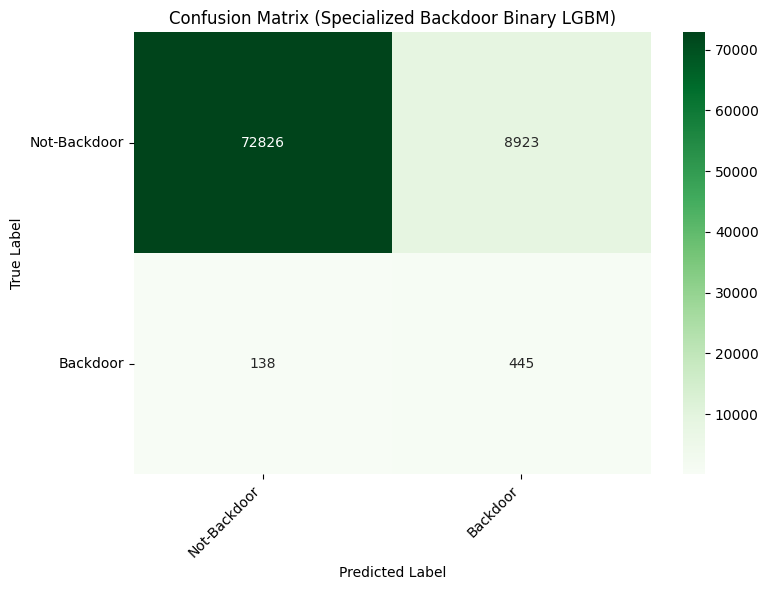

In [83]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix

print('\n--- Training Specialized LGBMClassifier for Backdoor vs. Not-Backdoor ---')

lgbm_backdoor_binary = lgb.LGBMClassifier(
    objective='binary', # Binary classification
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31
)

# Train the binary classifier on the resampled training data
lgbm_backdoor_binary.fit(X_train_binary_backdoor_resampled, y_train_binary_backdoor_resampled)

print('Specialized LGBMClassifier (Backdoor vs. Not-Backdoor) training complete.')

# Make predictions on the test set
y_pred_backdoor_binary = lgbm_backdoor_binary.predict(X_test_selected)
y_pred_proba_backdoor_binary = lgbm_backdoor_binary.predict_proba(X_test_selected)[:, 1] # Probability of being 'Backdoor'

# Evaluate the specialized binary classifier
report_backdoor_binary = classification_report(y_test_binary_backdoor, y_pred_backdoor_binary, target_names=['Not-Backdoor', 'Backdoor'])
print('\n--- Classification Report (Specialized Backdoor Binary LGBM) ---')
print(report_backdoor_binary)

cm_backdoor_binary = confusion_matrix(y_test_binary_backdoor, y_pred_backdoor_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_backdoor_binary, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not-Backdoor', 'Backdoor'], yticklabels=['Not-Backdoor', 'Backdoor'])
plt.title('Confusion Matrix (Specialized Backdoor Binary LGBM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Ensemble Strategy: Refine Multi-Class Predictions with Specialized Binary Classifier

Now we will combine the predictions from the main multi-class LGBM model and the specialized 'Backdoor' binary LGBM model. The strategy is as follows:

1.  Start with the predictions from the multi-class LGBM model (`y_pred_lgbm_multi_class`).
2.  For any samples where the multi-class model did *not* predict 'Backdoor',
3.  Check the prediction (or probability) from the specialized 'Backdoor' binary classifier (`lgbm_backdoor_binary`).
4.  If the specialized binary classifier strongly predicts 'Backdoor' (e.g., probability above a certain threshold, or direct prediction of 'Backdoor'), then we can override the multi-class prediction for that sample to 'Backdoor'.

This aims to boost the recall for 'Backdoor' by leveraging the focused expertise of the binary model.

Analyzing Precision-Recall trade-off for 'Backdoor'...


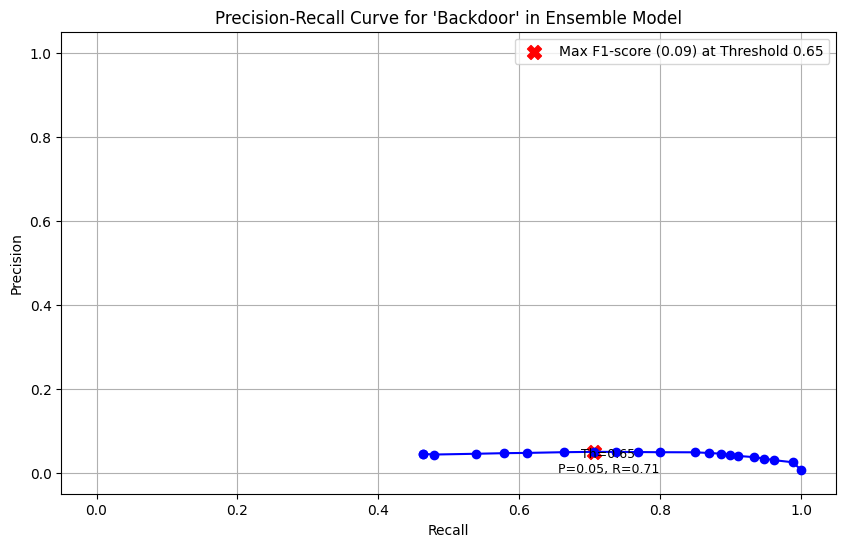


--- Re-evaluating Ensemble with default binary threshold (0.5) for final report ---
Number of samples where multi-class prediction was overridden to 'Backdoor' (threshold 0.5): 3604

--- Multi-Class Classification Report (LGBM Ensemble, threshold 0.5) ---
                precision    recall  f1-score   support

      Analysis       0.01      0.02      0.02       677
      Backdoor       0.05      0.80      0.09       583
           DoS       0.26      0.09      0.14      4089
      Exploits       0.76      0.53      0.63     11132
       Fuzzers       0.23      0.59      0.33      6062
       Generic       1.00      0.96      0.98     18871
        Normal       0.98      0.60      0.74     37000
Reconnaissance       0.52      0.72      0.60      3496
     Shellcode       0.23      0.60      0.33       378
         Worms       0.38      0.11      0.18        44

      accuracy                           0.65     82332
     macro avg       0.44      0.50      0.40     82332
  weighted av

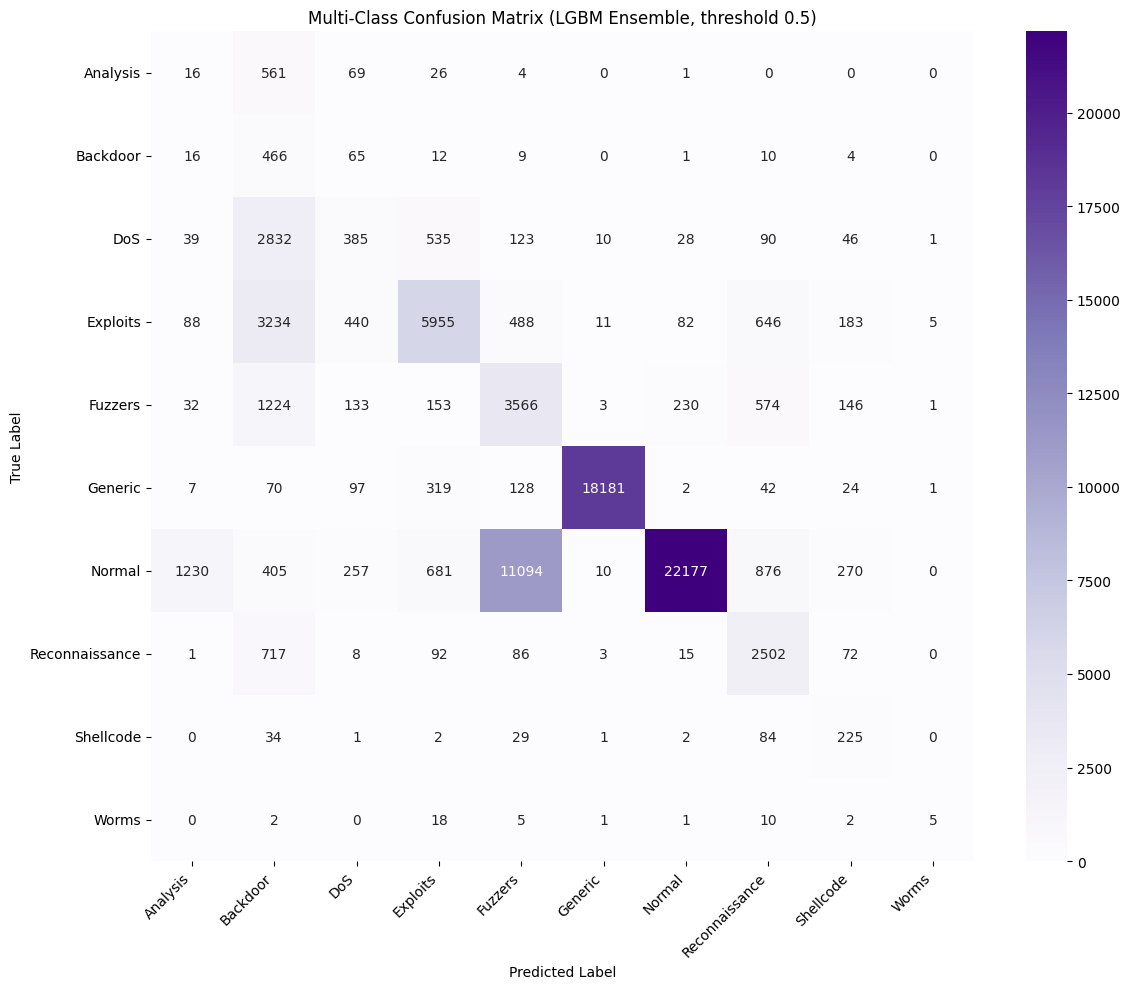

In [86]:
import matplotlib.pyplot as plt

# Get the encoded label for 'Backdoor' for comparison
backdoor_label_encoded = label_encoder.transform(['Backdoor'])[0]

# Condition 1: Multi-class model did not predict 'Backdoor' (this mask is constant across thresholds)
not_predicted_backdoor_by_multi_class = (y_pred_lgbm_multi_class != backdoor_label_encoded)

# --- Precision-Recall Trade-off Analysis ---
# Define a range of probability thresholds to evaluate
probability_thresholds = np.arange(0.0, 1.01, 0.05) # From 0.0 to 1.0 with 0.05 steps
precisions = []
recalls = []
f1_scores = []
overridden_counts = []

print("Analyzing Precision-Recall trade-off for 'Backdoor'...")

for threshold in probability_thresholds:
    # Start with predictions from the multi-class LGBM model
    y_pred_ensemble_temp = np.copy(y_pred_lgbm_multi_class)

    # Condition 2: Specialized binary model predicted 'Backdoor' at current threshold
    # Use probabilities to apply the threshold
    predicted_backdoor_by_binary_at_threshold = (y_pred_proba_backdoor_binary >= threshold)

    # Combine conditions to find samples where the override should occur
    override_mask_temp = not_predicted_backdoor_by_multi_class & predicted_backdoor_by_binary_at_threshold

    # Apply the override: change the ensemble prediction to 'Backdoor' for these samples
    y_pred_ensemble_temp[override_mask_temp] = backdoor_label_encoded

    # Calculate metrics for the current threshold
    # Using output_dict=True to easily extract class-specific metrics
    report_temp = classification_report(y_test_encoded, y_pred_ensemble_temp, target_names=class_names, output_dict=True, zero_division=0)

    # Store metrics for 'Backdoor' class
    precisions.append(report_temp['Backdoor']['precision'])
    recalls.append(report_temp['Backdoor']['recall'])
    f1_scores.append(report_temp['Backdoor']['f1-score'])
    overridden_counts.append(np.sum(override_mask_temp))

# Plotting the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='o', linestyle='-', color='b')
plt.title("Precision-Recall Curve for 'Backdoor' in Ensemble Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

# Annotate the point with the maximum F1-score
optimal_f1_idx = np.argmax(f1_scores)
plt.scatter(recalls[optimal_f1_idx], precisions[optimal_f1_idx], color='red', marker='X', s=100, label=f'Max F1-score ({f1_scores[optimal_f1_idx]:.2f}) at Threshold {probability_thresholds[optimal_f1_idx]:.2f}')
plt.annotate(f'Th={probability_thresholds[optimal_f1_idx]:.2f}\nP={precisions[optimal_f1_idx]:.2f}, R={recalls[optimal_f1_idx]:.2f}',
             (recalls[optimal_f1_idx], precisions[optimal_f1_idx]),
             textcoords="offset points", xytext=(10,-15), ha='center', fontsize=9)

plt.legend()
plt.show()

# --- Re-evaluate with the original default threshold (0.5) for consistency with previous discussion ---
print(f"\n--- Re-evaluating Ensemble with default binary threshold (0.5) for final report ---")

y_pred_ensemble_final = np.copy(y_pred_lgbm_multi_class)

# The default prediction from lgbm_backdoor_binary.predict() uses a 0.5 threshold.
# So, for consistency with previous output, we apply threshold 0.5 to probabilities.
predicted_backdoor_by_binary_default_threshold = (y_pred_proba_backdoor_binary >= 0.5)

override_mask_final = not_predicted_backdoor_by_multi_class & predicted_backdoor_by_binary_default_threshold
y_pred_ensemble_final[override_mask_final] = backdoor_label_encoded

print(f"Number of samples where multi-class prediction was overridden to 'Backdoor' (threshold 0.5): {np.sum(override_mask_final)}")

# Evaluate the ensemble model with default threshold
report_ensemble_final = classification_report(y_test_encoded, y_pred_ensemble_final, target_names=class_names, zero_division=0)
print('\n--- Multi-Class Classification Report (LGBM Ensemble, threshold 0.5) ---')
print(report_ensemble_final)

# Display ensemble confusion matrix with default threshold
cm_ensemble_final = confusion_matrix(y_test_encoded, y_pred_ensemble_final)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_ensemble_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Multi-Class Confusion Matrix (LGBM Ensemble, threshold 0.5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [45]:

# =====================================================================
# MODULE 3: SUBSPACE LEARNING MACHINE (SLM) TREE CLASSIFIER
# =====================================================================
class SLMTreeNode:
    """Internal structural node for the Subspace Learning Machine Tree."""
    def __init__(self, depth=0, max_depth=10, min_samples_split=5):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.w = None          # Projection hyperplane vector (w_opt)
        self.threshold = None  # Split boundary point (phi)
        self.left = None       # Left child node
        self.right = None      # Right child node
        self.is_leaf = False
        self.probs = None      # Class probability distribution mapping

class SLMTreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Subspace Learning Machine (SLM) Tree Classifier.
    Implements multi-class oblique splits using probabilistic direction search.
    """
    def __init__(self, max_depth=10, min_samples_split=5, num_proj_candidates=50, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.num_proj_candidates = num_proj_candidates
        self.random_state = random_state
        self.root = None
        self.classes_ = None

    def _calculate_entropy(self, y):
        if len(y) == 0: return 0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-9))

    def _find_best_oblique_split(self, X, y, rng):
        num_samples, num_features = X.shape
        best_entropy = float('inf')
        best_w = None
        best_t = None

        # Step 1: Generate projection vector candidates (Probabilistic Search Strategy)
        candidates = []
        # Include baseline axis-aligned vectors
        for i in range(min(num_features, self.num_proj_candidates // 2)):
            w = np.zeros(num_features)
            w[i] = 1.0
            candidates.append(w)

        # Sample random oblique projections (combinations of multiple feature vectors)
        while len(candidates) < self.num_proj_candidates:
            w = rng.normal(0, 1, size=num_features)
            norm = np.linalg.norm(w)
            if norm > 0:
                candidates.append(w / norm)

        # Step 2: Project data onto 1D subspace and locate the optimal split point
        for w in candidates:
            X_projected = np.dot(X, w)
            # Evaluate splitting boundaries on data percentiles
            split_targets = np.percentile(X_projected, [10, 25, 50, 75, 90])

            for t in split_targets:
                left_mask = X_projected < t
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                w_left = np.sum(left_mask) / num_samples
                w_right = np.sum(right_mask) / num_samples

                entropy_split = (w_left * self._calculate_entropy(y[left_mask]) +
                                 w_right * self._calculate_entropy(y[right_mask]))

                if entropy_split < best_entropy:
                    best_entropy = entropy_split
                    best_w = w
                    best_t = t

        return best_w, best_t, best_entropy

    def _build_tree(self, X, y, node, rng):
        num_samples = X.shape[0]
        unique_classes, counts = np.unique(y, return_counts=True)

        # Calculate class distribution maps for this boundary
        node.probs = {c: 0.0 for c in self.classes_}
        for c, count in zip(unique_classes, counts):
            node.probs[c] = count / num_samples

        # Evaluate terminal conditions
        if (node.depth >= node.max_depth or
            num_samples < node.min_samples_split or
            len(unique_classes) == 1):
            node.is_leaf = True
            return

        # Execute Oblique Subspace Hyperplane Split
        w, t, split_ent = self._find_best_oblique_split(X, y, rng)
        if w is None or t is None: # Corrected typo 'desertion' to 'is None'
            node.is_leaf = True
            return
        node.w = w # Corrected indentation
        node.threshold = t # Corrected indentation

        # Partition feature mappings downstream
        X_projected = np.dot(X, w)
        left_mask = X_projected < t

        if np.sum(left_mask) == 0 or np.sum(~left_mask) == 0:
            node.is_leaf = True
            return

        node.left = SLMTreeNode(depth=node.depth + 1, max_depth=node.max_depth, min_samples_split=node.min_samples_split)
        node.right = SLMTreeNode(depth=node.depth + 1, max_depth=node.max_depth, min_samples_split=node.min_samples_split)

        self._build_tree(X[left_mask], y[left_mask], node.left, rng)
        self._build_tree(X[~left_mask], y[~left_mask], node.right, rng)

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        rng = np.random.default_rng(self.random_state)
        self.root = SLMTreeNode(depth=0, max_depth=self.max_depth, min_samples_split=self.min_samples_split)
        self._build_tree(X, y, self.root, rng)
        return self

    def _predict_sample(self, x, node):
        if node.is_leaf:
            return node.probs
        # Use equation: w^T * f - phi to check structural partition direction
        if np.dot(x, node.w) < node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict_proba(self, X):
        proba_list = [self._predict_sample(x, self.root) for x in X]
        return np.array([[p[c] for c in self.classes_] for p in proba_list])

    def predict(self, X):
        probas = self.predict_proba(X)
        return self.classes_[np.argmax(probas, axis=1)]

In [50]:
print("\nInitializing and Training SLMTreeClassifier...")
slm_classifier = SLMTreeClassifier(max_depth=8, min_samples_split=10, num_proj_candidates=40, random_state=42)
slm_classifier.fit(X_train_binary.values, y_train_binary)
print("SLMTreeClassifier training complete.")


Initializing and Training SLMTreeClassifier...
SLMTreeClassifier training complete.


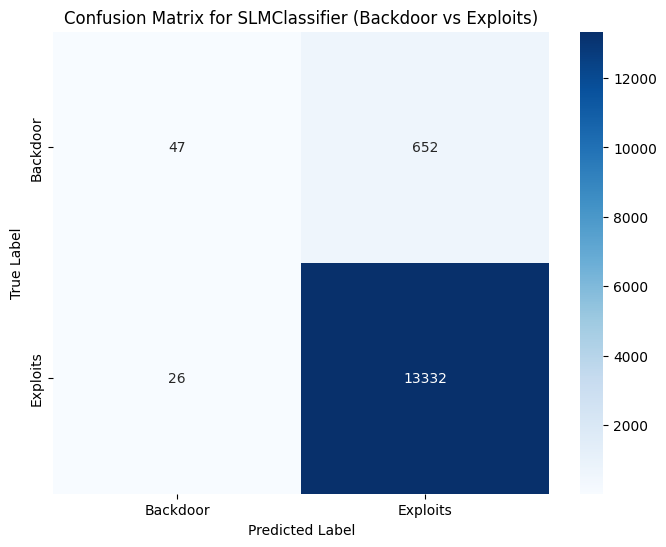

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
predictions_binary = slm_classifier.predict(X_test_binary.values)

# Compute the confusion matrix
cm_slm = confusion_matrix(y_test_binary, predictions_binary)

# Define the class labels for the binary classification ('Backdoor' vs 'Exploits')
# Assuming 0 for 'Backdoor' and 1 for 'Exploits' based on previous context.
# It's important to verify the order of classes from label_encoder or other mapping.
# If `y_binary` was created from `label_encoder.fit_transform(binary_df['attack_cat'])`,
# then `label_encoder.classes_` would give the order.
# Let's assume for now that 0 is 'Backdoor' and 1 is 'Exploits' or similar.

# To be robust, let's derive the binary class names from the unique values in y_binary_raw
# This assumes y_binary_raw is available and contains the original string labels for the binary subset.
# If not, you might need to adjust this part or ensure the `target_classes` variable from the original context is used correctly.

# From context, target_classes was ['Backdoor', 'Exploits']
# Assuming y_binary was encoded such that 'Backdoor' maps to 0 and 'Exploits' maps to 1
binary_class_names = ['Backdoor', 'Exploits'] # Adjust if the order is different in your encoding

plt.figure(figsize=(8, 6))
sns.heatmap(cm_slm, annot=True, fmt='d', cmap='Blues',
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix for SLMClassifier (Backdoor vs Exploits)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier

print("\nInitializing and Training RandomForestClassifier...")
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_binary.values, y_train_binary)
print("RandomForestClassifier training complete.")


Initializing and Training RandomForestClassifier...
RandomForestClassifier training complete.


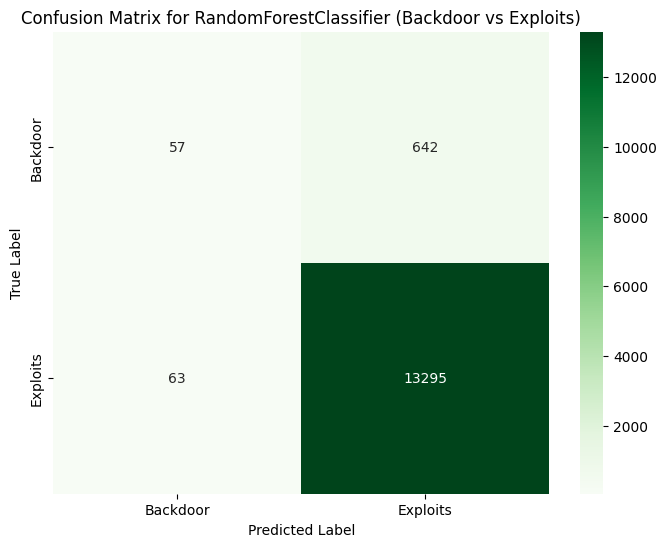

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set using RandomForest
predictions_rf = rf_classifier.predict(X_test_binary.values)

# Compute the confusion matrix for RandomForest
cm_rf = confusion_matrix(y_test_binary, predictions_rf)

# Assuming binary_class_names is already defined from previous cells
# binary_class_names = ['Backdoor', 'Exploits']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix for RandomForestClassifier (Backdoor vs Exploits)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Balancing the Dataset using SMOTE

To address the class imbalance and potentially improve the detection of the 'Backdoor' class, we can use oversampling techniques like SMOTE (Synthetic Minority Over-sampling Technique). SMOTE works by creating synthetic samples from the minority class, helping to balance the class distribution in the training data.

In [56]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train_binary.shape, y_train_binary.shape)
print("Original 'Backdoor' class count:", np.sum(y_train_binary == 0))
print("Original 'Exploits' class count:", np.sum(y_train_binary == 1))

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_binary, y_train_binary)

print("Resampled training set shape:", X_train_res.shape, y_train_res.shape)
print("Resampled 'Backdoor' class count:", np.sum(y_train_res == 0))
print("Resampled 'Exploits' class count:", np.sum(y_train_res == 1))

Original training set shape: (32797, 193) (32797,)
Original 'Backdoor' class count: 1630
Original 'Exploits' class count: 31167
Resampled training set shape: (62334, 193) (62334,)
Resampled 'Backdoor' class count: 31167
Resampled 'Exploits' class count: 31167


In [57]:
print("\nRetraining SLMTreeClassifier with resampled data...")
slm_classifier_resampled = SLMTreeClassifier(max_depth=8, min_samples_split=10, num_proj_candidates=40, random_state=42)
slm_classifier_resampled.fit(X_train_res.values, y_train_res)
print("SLMTreeClassifier retraining complete with resampled data.")


Retraining SLMTreeClassifier with resampled data...
SLMTreeClassifier retraining complete with resampled data.


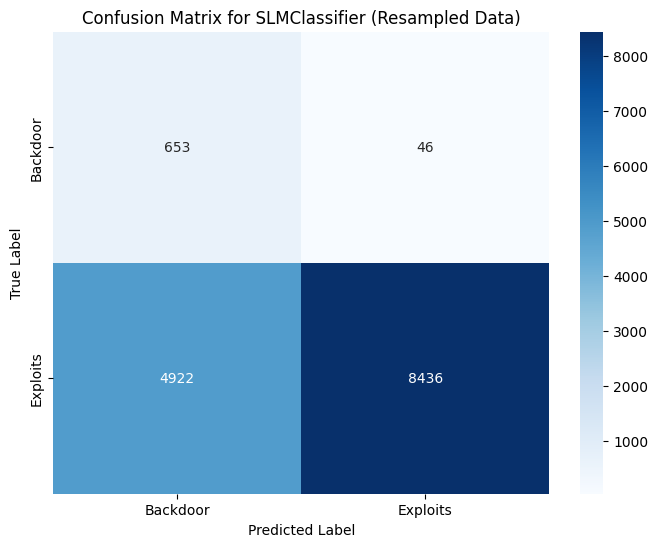

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set using the resampled SLMClassifier
predictions_binary_resampled_slm = slm_classifier_resampled.predict(X_test_binary.values)

# Compute the confusion matrix for the resampled SLMClassifier
cm_slm_resampled = confusion_matrix(y_test_binary, predictions_binary_resampled_slm)

# Use the predefined binary_class_names

plt.figure(figsize=(8, 6))
sns.heatmap(cm_slm_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix for SLMClassifier (Resampled Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

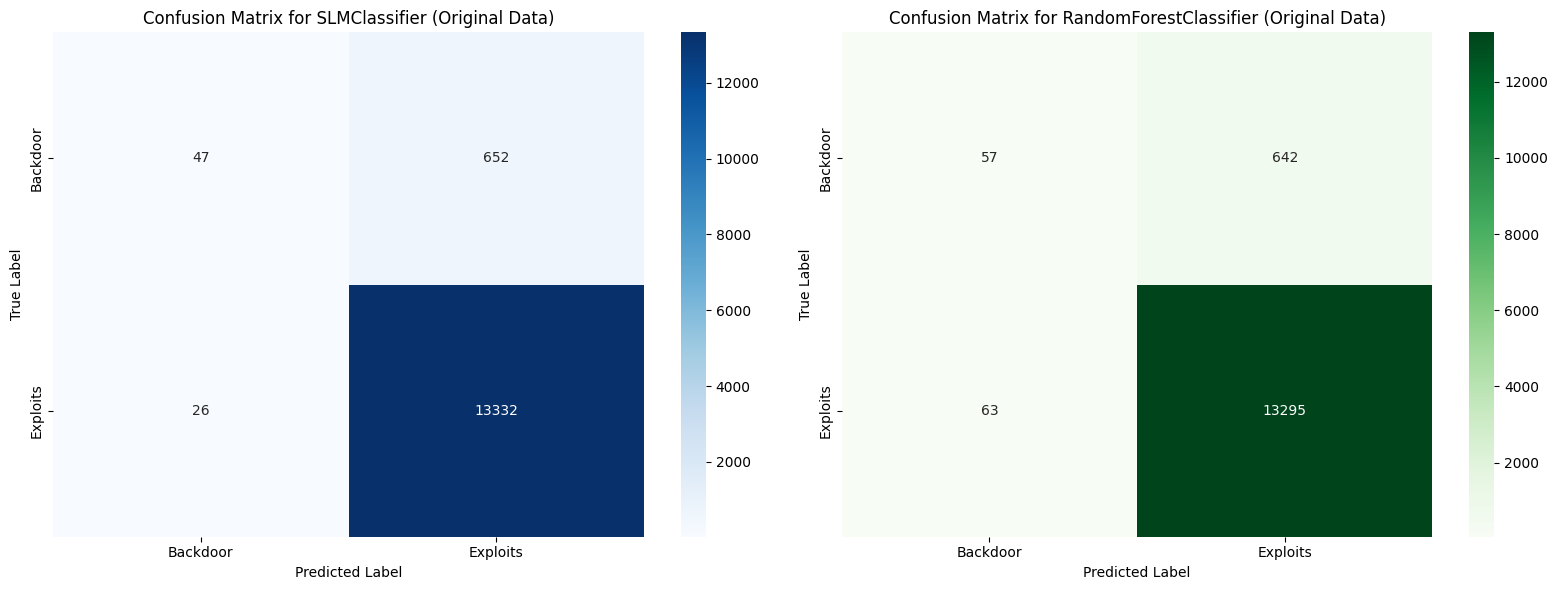

In [59]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_slm, annot=True, fmt='d', cmap='Blues',
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix for SLMClassifier (Original Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=binary_class_names, yticklabels=binary_class_names)
plt.title('Confusion Matrix for RandomForestClassifier (Original Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [60]:
from sklearn.metrics import classification_report

# Generate classification report for the SMOTE-trained SLMClassifier
report_slm_resampled = classification_report(y_test_binary, predictions_binary_resampled_slm, target_names=binary_class_names)
print("Classification Report for SLMClassifier (Resampled Data):\n")
print(report_slm_resampled)

Classification Report for SLMClassifier (Resampled Data):

              precision    recall  f1-score   support

    Backdoor       0.12      0.93      0.21       699
    Exploits       0.99      0.63      0.77     13358

    accuracy                           0.65     14057
   macro avg       0.56      0.78      0.49     14057
weighted avg       0.95      0.65      0.74     14057



In [61]:
# Generate classification report for the original SLMClassifier
report_slm_original = classification_report(y_test_binary, predictions_binary, target_names=binary_class_names)
print("Classification Report for SLMClassifier (Original Data):\n")
print(report_slm_original)

Classification Report for SLMClassifier (Original Data):

              precision    recall  f1-score   support

    Backdoor       0.64      0.07      0.12       699
    Exploits       0.95      1.00      0.98     13358

    accuracy                           0.95     14057
   macro avg       0.80      0.53      0.55     14057
weighted avg       0.94      0.95      0.93     14057



In [62]:
# Generate classification report for the RandomForestClassifier
report_rf_original = classification_report(y_test_binary, predictions_rf, target_names=binary_class_names)
print("Classification Report for RandomForestClassifier (Original Data):\n")
print(report_rf_original)

Classification Report for RandomForestClassifier (Original Data):

              precision    recall  f1-score   support

    Backdoor       0.47      0.08      0.14       699
    Exploits       0.95      1.00      0.97     13358

    accuracy                           0.95     14057
   macro avg       0.71      0.54      0.56     14057
weighted avg       0.93      0.95      0.93     14057

